In [1]:
# ============================================================
# BRAIN TUMOR DETECTION PROJECT - PHASE 1
# DATA PREPARATION, AUGMENTATION AND PREPROCESSING
# ============================================================


# =========================
# IMPORT REQUIRED LIBRARIES
# =========================

import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imutils

from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# For displaying graphs inside Jupyter Notebook
%matplotlib inline

In [2]:
# =========================
# EXTRACT DATASET
# =========================

# Extract the zip file containing the dataset

zip_path = r'C:\Users\Arya\Desktop\ICT_Project\archive.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall()

print("Dataset extracted successfully")

Dataset extracted successfully


In [3]:
# ============================================================
# RENAME IMAGES
# ============================================================
# Renaming images gives unique and organized filenames
# Example:
# yes images -> Y_1.jpg, Y_2.jpg ...
# no images  -> N_1.jpg, N_2.jpg ...
# ============================================================

# Path of tumor images
yes_folder = 'brain_tumor_dataset/yes/'

count = 1

for filename in os.listdir(yes_folder):

    source = yes_folder + filename
    destination = yes_folder + "Y_" + str(count) + ".jpg"

    os.rename(source, destination)

    count += 1

print("Tumor images renamed successfully")


# Path of non-tumor images
no_folder = 'brain_tumor_dataset/no/'

count = 1

for filename in os.listdir(no_folder):

    source = no_folder + filename
    destination = no_folder + "N_" + str(count) + ".jpg"

    os.rename(source, destination)

    count += 1

print("Non-tumor images renamed successfully")

Tumor images renamed successfully
Non-tumor images renamed successfully


In [4]:
# ============================================================
# DISPLAY DATASET INFORMATION
# ============================================================

yes_images = len(os.listdir(yes_folder))
no_images = len(os.listdir(no_folder))

print(f"Number of Tumor Images     : {yes_images}")
print(f"Number of Non-Tumor Images : {no_images}")

Number of Tumor Images     : 155
Number of Non-Tumor Images : 98


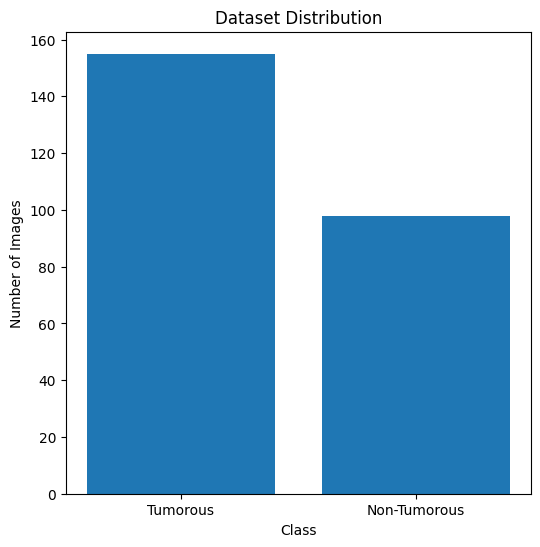

In [5]:
# ============================================================
# VISUALIZE DATA DISTRIBUTION
# ============================================================

data = {
    'Tumorous': yes_images,
    'Non-Tumorous': no_images
}

plt.figure(figsize=(6,6))

plt.bar(data.keys(), data.values())

plt.title("Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [6]:
# ============================================================
# DATA AUGMENTATION
# ============================================================
# Data augmentation artificially creates more training images.
#
# Transformations used:
# - rotation
# - width shift
# - height shift
# - brightness change
# - flipping
#
# This helps improve model accuracy and reduce overfitting.
# ============================================================

def augment_data(file_dir, n_generated_samples, save_to_dir):

    # Create ImageDataGenerator object
    data_gen = ImageDataGenerator(

        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        brightness_range=(0.3, 1.0),
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )

    # Loop through each image
    for filename in os.listdir(file_dir):

        image_path = file_dir + '/' + filename

        # Read image using OpenCV
        image = cv2.imread(image_path)

        # Skip if image not loaded
        if image is None:
            continue

        # Reshape image because generator expects 4D input
        image = image.reshape((1,) + image.shape)

        save_prefix = 'aug_' + filename[:-4]

        i = 0

        # Generate augmented images
        for batch in data_gen.flow(
                x=image,
                batch_size=1,
                save_to_dir=save_to_dir,
                save_prefix=save_prefix,
                save_format='jpg'):

            i += 1

            # Stop after generating required samples
            if i > n_generated_samples:
                break

In [8]:
# ============================================================
# CREATE AUGMENTED DATA
# ============================================================

augment_data(
    file_dir='brain_tumor_dataset/yes',
    n_generated_samples=6,
    save_to_dir='augmented_data/yes'
)

augment_data(
    file_dir='brain_tumor_dataset/no',
    n_generated_samples=9,
    save_to_dir='augmented_data/no'
)

print("Data augmentation completed")

Data augmentation completed


In [9]:
# ============================================================
# CROPPING BRAIN REGION
# ============================================================
# Removes unnecessary black background from MRI image
# and keeps only the important brain region.
# ============================================================

def crop_brain_tumor(image, plot=False):

    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian Blur to reduce noise
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply thresholding
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]

    # Remove small noises
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Find contours
    cnts = cv2.findContours(
        thresh.copy(),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cnts = imutils.grab_contours(cnts)

    # Find largest contour
    c = max(cnts, key=cv2.contourArea)

    # Find extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # Crop image
    new_image = image[
        extTop[1]:extBot[1],
        extLeft[0]:extRight[0]
    ]

    # Plot images if required
    if plot:

        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.imshow(image)
        plt.title("Original Image")

        plt.subplot(1,2,2)
        plt.imshow(new_image)
        plt.title("Cropped Image")

        plt.show()

    return new_image

In [10]:
# ============================================================
# APPLY CROPPING TO ALL IMAGES
# ============================================================

folders = ['augmented_data/yes/', 'augmented_data/no/']

for folder in folders:

    for filename in os.listdir(folder):

        image_path = folder + filename

        image = cv2.imread(image_path)

        if image is None:
            continue

        cropped_image = crop_brain_tumor(image)

        cv2.imwrite(image_path, cropped_image)

print("Cropping completed")

Cropping completed


In [11]:
# ============================================================
# LOAD AND PREPROCESS DATA
# ============================================================
# Steps:
# 1. Read image
# 2. Crop brain region
# 3. Resize image
# 4. Normalize pixel values
# 5. Assign labels
# ============================================================

def load_data(dir_list, image_size):

    X = []
    y = []

    image_width, image_height = image_size

    for directory in dir_list:

        for filename in os.listdir(directory):

            image_path = directory + '/' + filename

            image = cv2.imread(image_path)

            if image is None:
                continue

            # Crop brain area
            image = crop_brain_tumor(image)

            # Resize image
            image = cv2.resize(
                image,
                dsize=(image_width, image_height),
                interpolation=cv2.INTER_CUBIC
            )

            # Normalize image
            image = image / 255.0

            X.append(image)

            # Assign label
            if directory.endswith('yes'):
                y.append(1)
            else:
                y.append(0)

    X = np.array(X)
    y = np.array(y)

    # Shuffle dataset
    X, y = shuffle(X, y)

    print(f"Total Images : {len(X)}")
    print(f"X Shape      : {X.shape}")
    print(f"Y Shape      : {y.shape}")

    return X, y

In [ ]:
# ============================================================
# LOAD FINAL PREPROCESSED DATA
# ============================================================

IMAGE_WIDTH = 240
IMAGE_HEIGHT = 240

X, y = load_data(
    ['augmented_data/yes', 'augmented_data/no'],
    (IMAGE_WIDTH, IMAGE_HEIGHT)
)

print("Preprocessing completed successfully")